In [1]:
from google.colab import drive;
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [5]:
df=pd.read_csv('/content/drive/MyDrive/Ostad_Data_set/ML_datasets/heart_disease_uci.csv')
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [7]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [8]:
df=df.drop(['sex','dataset','cp','fbs','restecg','exang','slope','ca','thal'],axis=1)
df

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0
...,...,...,...,...,...,...,...
915,916,54,127.0,333.0,154.0,0.0,1
916,917,62,NaN,139.0,NaN,NaN,0
917,918,55,122.0,223.0,100.0,0.0,2
918,919,58,NaN,385.0,NaN,NaN,0


In [9]:
df.head()

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0


In [10]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [11]:
missing__values=df.isnull().sum()
print(f"missing-values:{missing__values}")

missing-values:id           0
age          0
trestbps    59
chol        30
thalch      55
oldpeak     62
num          0
dtype: int64


In [12]:
df.shape

(920, 7)

In [13]:
df_cleaned=df.dropna()
df_cleaned.head()

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0


In [14]:
df_cleaned.shape

(827, 7)

In [17]:
df.columns

Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')

In [15]:
##Removing the outliers from the dataset
import seaborn as sns;

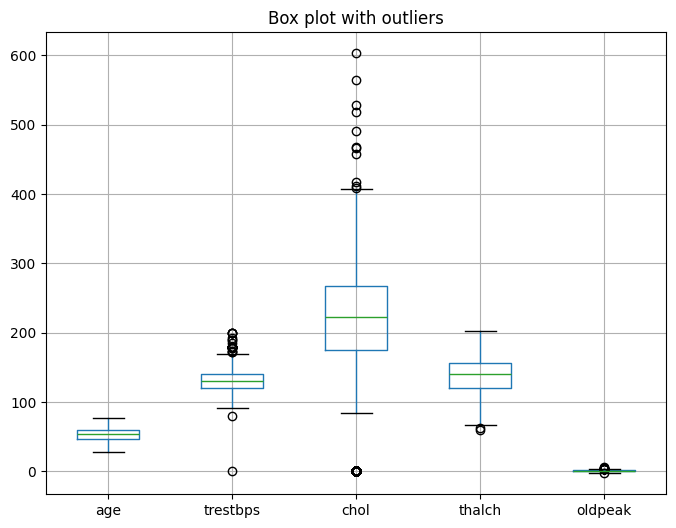

In [19]:
plt.figure(figsize=(8,6))
df.boxplot(column=['age','trestbps','chol','thalch','oldpeak'])
plt.title("Box plot with outliers")
plt.show()

In [21]:
##define a function for removing oitliers
def removing__outLiers(df,columns=None):
  clear_df=df.copy();
  for col in columns:
    Q1=clear_df[col].quantile(0.25)
    Q3=clear_df[col].quantile(0.75)
    IQR=Q3-Q1;
    lower_bound=Q1-1.5*IQR;
    uppesr_bound=Q3+1.5*IQR;
    clear_df=clear_df[(clear_df[col]>=lower_bound) & (clear_df[col]<=uppesr_bound)]
  return clear_df;

In [23]:
columns=['trestbps','chol','thalch','oldpeak']
df_cleaned=removing__outLiers(df_cleaned,columns)


In [24]:
df_cleaned.shape

(628, 7)

In [25]:
print(df_cleaned.info)

<bound method DataFrame.info of       id  age  trestbps   chol  thalch  oldpeak  num
0      1   63     145.0  233.0   150.0      2.3    0
1      2   67     160.0  286.0   108.0      1.5    2
2      3   67     120.0  229.0   129.0      2.6    1
3      4   37     130.0  250.0   187.0      3.5    0
4      5   41     130.0  204.0   172.0      1.4    0
..   ...  ...       ...    ...     ...      ...  ...
913  914   62     158.0  170.0   138.0      0.0    1
914  915   46     134.0  310.0   126.0      0.0    2
915  916   54     127.0  333.0   154.0      0.0    1
917  918   55     122.0  223.0   100.0      0.0    2
919  920   62     120.0  254.0    93.0      0.0    1

[628 rows x 7 columns]>


In [26]:
print(df_cleaned.describe)

<bound method NDFrame.describe of       id  age  trestbps   chol  thalch  oldpeak  num
0      1   63     145.0  233.0   150.0      2.3    0
1      2   67     160.0  286.0   108.0      1.5    2
2      3   67     120.0  229.0   129.0      2.6    1
3      4   37     130.0  250.0   187.0      3.5    0
4      5   41     130.0  204.0   172.0      1.4    0
..   ...  ...       ...    ...     ...      ...  ...
913  914   62     158.0  170.0   138.0      0.0    1
914  915   46     134.0  310.0   126.0      0.0    2
915  916   54     127.0  333.0   154.0      0.0    1
917  918   55     122.0  223.0   100.0      0.0    2
919  920   62     120.0  254.0    93.0      0.0    1

[628 rows x 7 columns]>


In [27]:
x=df_cleaned.drop('num',axis=1)
y=df_cleaned['num']


In [29]:
features_columns=x.columns.to_list()
features_columns

['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak']

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
from sklearn.preprocessing import StandardScaler

In [41]:
model=RandomForestClassifier()
model.fit(x_train,y_train)


RandomForestClassifier()

In [33]:
y_pred=model.predict(x_test)
y_pred

array([1, 2, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 3, 0, 1, 1, 0, 0, 3, 0, 0, 0, 0, 0, 1, 3, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 3, 0, 0, 0, 4, 2, 0, 0, 2, 0, 0,
       3, 0, 0, 0, 0, 2, 0, 0, 3, 2, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 3, 0, 0])

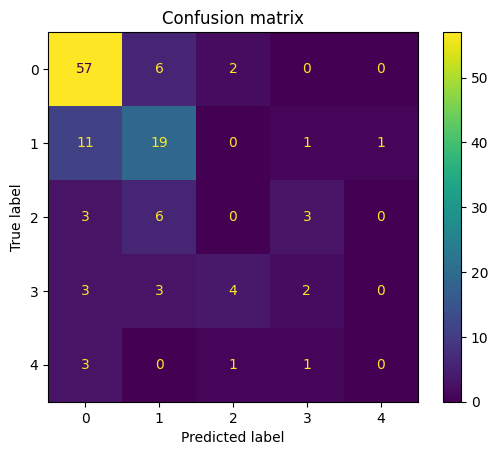

In [35]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion matrix")
plt.show()

In [37]:
df_cleaned['num'].value_counts()

,count
num,
0,342
1,172
2,54
3,48
4,12


In [38]:
print("classification report")
print(classification_report(y_test,y_pred))

classification report
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        65
           1       0.56      0.59      0.58        32
           2       0.00      0.00      0.00        12
           3       0.29      0.17      0.21        12
           4       0.00      0.00      0.00         5

    accuracy                           0.62       126
   macro avg       0.32      0.33      0.32       126
weighted avg       0.55      0.62      0.58       126



#After-Scaling

In [61]:
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [62]:
model=RandomForestClassifier()
model.fit(x_train_scaler,y_train)


RandomForestClassifier()

In [63]:
y_pred=model.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred)


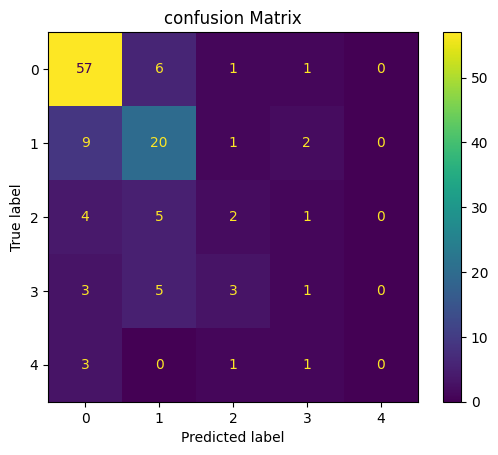

In [64]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("confusion Matrix")
plt.show()

In [65]:
print("classification report")
print(classification_report(y_test,y_pred))

classification report
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        65
           1       0.56      0.62      0.59        32
           2       0.25      0.17      0.20        12
           3       0.17      0.08      0.11        12
           4       0.00      0.00      0.00         5

    accuracy                           0.63       126
   macro avg       0.34      0.35      0.34       126
weighted avg       0.57      0.63      0.60       126



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [73]:
def predict_heart_disease(input_data:dict):
  input_df=pd.DataFrame([input_data])
  input_df=input_df[features_columns]
  prediction=model.predict(input_df)[0]
  prediction_probability=model.predict_proba(input_df)[0]
  print(f"Prediction Category:{prediction}")
  print(f"Prediction confidence:{prediction_probability}")
sample_input={
    'id':14,
    'age':44,
    'sex':'male',
    'cp':'asymtomatic',
    'trestbps':120,
    'chol':263,
    'fbs':'False',
    'restecg':'lv hypertrophy',
    'thalch':160,
    'exang':'True',
    'oldpeak':1.3,
    'slope':'flat',
    'ca':2,
    'thal':'normal'
}

predict_heart_disease(sample_input)

Prediction Category:2
Prediction confidence:[0.21 0.14 0.35 0.29 0.01]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
